# Isolation Forest | Anomaly Detection

Isolation Forest builds an ensemble of random trees that isolate points by recursively partitioning the feature space. Anomalies require fewer splits to isolate => shorter average path length => lower (more negative) anomaly score.

Two approaches:
- **Phase 1 Global IF**: fit on all 1,500 paintings (50 PCA dims), then stratify results by artist to see which artists contribute the most anomalies
- **Phase 2 Per-Artist IF**: fit a separate IF on each qualified artist's embeddings, reduced to 10 PCA dims to compensate for small sample sizes

Both approaches use `contamination=0.05` (top 5% flagged) for consistency with cosine, Wasserstein, and KS results.

**Prerequisite:** Run `src/reduce_embeddings.py` and all three prior analysis notebooks before the cross-method section.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

BASE_DIR       = Path('..')
EMBEDDINGS_DIR = BASE_DIR / 'embeddings'
RESULTS_DIR    = BASE_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

CONTAMINATION = 0.05  
N_ESTIMATORS  = 200 
RANDOM_STATE  = 42

# Load shared PCA-reduced embeddings
pca_path = EMBEDDINGS_DIR / 'embeddings_pca50.npy'
if not pca_path.exists():
    raise FileNotFoundError('embeddings_pca50.npy not found. Run: python src/reduce_embeddings.py')

embeddings_pca = np.load(pca_path)
metadata       = pd.read_csv(EMBEDDINGS_DIR / 'embedding_metadata.csv').reset_index(drop=True)

print('PCA embeddings shape :', embeddings_pca.shape)
print('Metadata shape       :', metadata.shape)

PCA embeddings shape : (1500, 50)
Metadata shape       : (1500, 11)


## Phase 1: Global Isolation Forest

We fit one IF on all 1,500 paintings. `decision_function` returns a score per painting:
- More negative =? further from the bulk => more anomalous
- We invert the sign so higher = more anomalous (consistent with other methods)

In [2]:
print('Fitting Global Isolation Forest...')
iso_global = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_global.fit(embeddings_pca)

# Raw score: more negative = more anomalous
# Invert so higher = more anomalous
global_if_scores  = -iso_global.decision_function(embeddings_pca)
global_if_labels  =  iso_global.predict(embeddings_pca)

# normalize scores 0-1
global_if_norm = (
    (global_if_scores - global_if_scores.min()) /
    (global_if_scores.max() - global_if_scores.min())
)

metadata['if_global_score'] = global_if_scores
metadata['if_global_norm']  = global_if_norm
metadata['if_global_flag']  = (global_if_labels == -1)

n_flagged = (global_if_labels == -1).sum()
print(f'Flagged as anomalies : {n_flagged} / {len(metadata)} ({n_flagged/len(metadata):.1%})')
print(f'Score mean : {global_if_scores.mean():.4f}')
print(f'Score std  : {global_if_scores.std():.4f}')
print(f'Score min  : {global_if_scores.min():.4f}')
print(f'Score max  : {global_if_scores.max():.4f}')

Fitting Global Isolation Forest...
Flagged as anomalies : 75 / 1500 (5.0%)
Score mean : -0.0334
Score std  : 0.0186
Score min  : -0.0751
Score max  : 0.0453


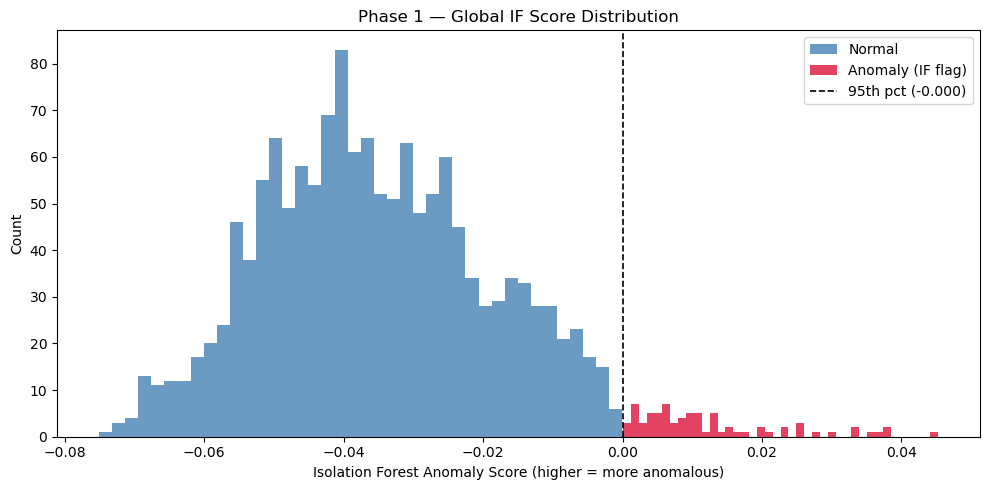

In [3]:
# Histogram of global IF scores
threshold = np.percentile(global_if_scores, 95)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(global_if_scores[global_if_labels == 1],  bins=40,
        color='steelblue', alpha=0.8, label='Normal')
ax.hist(global_if_scores[global_if_labels == -1], bins=40,
        color='crimson',   alpha=0.8, label='Anomaly (IF flag)')
ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2,
           label=f'95th pct ({threshold:.3f})')
ax.set_xlabel('Isolation Forest Anomaly Score (higher = more anomalous)')
ax.set_ylabel('Count')
ax.set_title('Phase 1 — Global IF Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_global_histogram.png', dpi=150)
plt.show()

c:\Users\Yeva\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


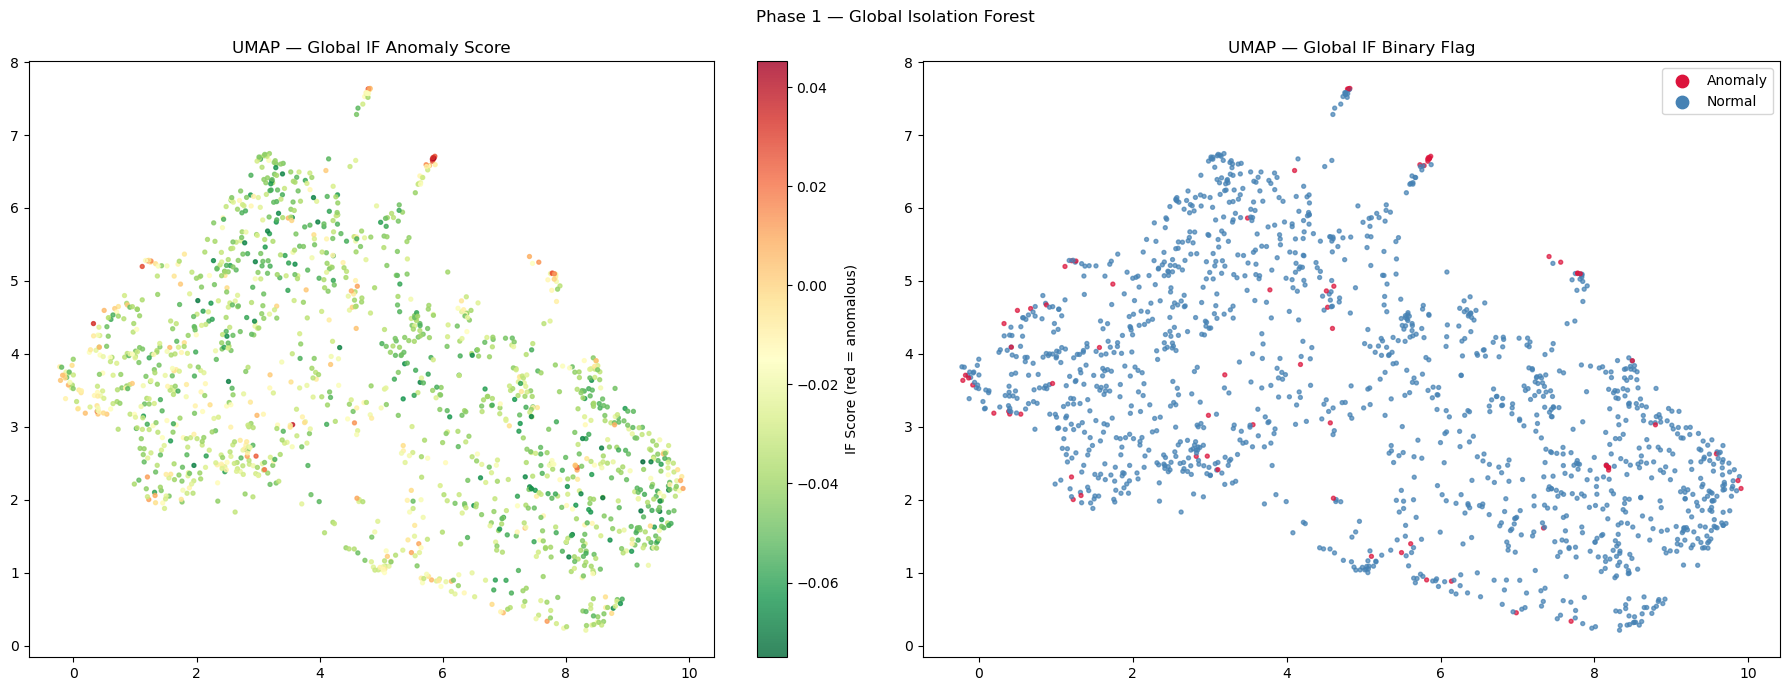

In [4]:
# UMAP coloured by global IF score
try:
    import umap
except ImportError:
    raise ImportError('Install umap-learn: pip install umap-learn')

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
coords  = reducer.fit_transform(embeddings_pca)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(coords[:, 0], coords[:, 1],
                     c=global_if_scores, cmap='RdYlGn_r', s=8, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='IF Score (red = anomalous)')
axes[0].set_title('UMAP — Global IF Anomaly Score')

colors = np.where(global_if_labels == -1, 'crimson', 'steelblue')
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors, s=8, alpha=0.7)
axes[1].scatter([], [], c='crimson',   s=20, label='Anomaly')
axes[1].scatter([], [], c='steelblue', s=20, label='Normal')
axes[1].legend(markerscale=2)
axes[1].set_title('UMAP — Global IF Binary Flag')

plt.suptitle('Phase 1 — Global Isolation Forest', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_global_umap.png', dpi=150)
plt.show()

In [5]:
# Top 20 anomalies (global IF)
top20_global = (
    metadata[['filename', 'artist', 'if_global_score', 'if_global_norm']]
    .sort_values('if_global_score', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
print('Top 20 anomalies — Global IF:')
print(top20_global.to_string(index=False))

Top 20 anomalies — Global IF:
                                                              filename                  artist  if_global_score  if_global_norm
                        Impressionism/claude-monet_ships-in-harbor.jpg            claude monet         0.045264        1.000000
                 Impressionism/eugene-boudin_the-port-at-deauville.jpg           eugene boudin         0.038393        0.942913
             Impressionism/claude-monet_water-lilies-nympheas-1907.jpg            claude monet         0.037838        0.938300
   Impressionism/eugene-boudin_trouville-the-port-at-low-tide-1887.jpg           eugene boudin         0.036252        0.925124
                 Impressionism/auguste-rodin_nude-study-for-balzac.jpg           auguste rodin         0.035693        0.920477
          Impressionism/pierre-auguste-renoir_cape-saint-jean-1910.jpg   pierre auguste renoir         0.033913        0.905687
            Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg    

### Artist Stratification

We break down global IF anomalies by artist to see which artists contribute the most flagged paintings, and which artists have the highest anomaly *rate* (anomalies as % of their total paintings).

In [6]:
MIN_IMAGES = 20
artist_counts     = metadata['artist'].value_counts()
qualified_artists = artist_counts[artist_counts >= MIN_IMAGES].index.tolist()

meta_qualified = metadata[metadata['artist'].isin(qualified_artists)].copy()

stratification = (
    meta_qualified.groupby('artist')
    .agg(
        n_total      =('if_global_flag', 'count'),
        n_anomalies  =('if_global_flag', 'sum'),
        mean_score   =('if_global_score', 'mean'),
        max_score    =('if_global_score', 'max')
    )
    .reset_index()
)
stratification['anomaly_rate'] = stratification['n_anomalies'] / stratification['n_total']
stratification = stratification.sort_values('anomaly_rate', ascending=False).reset_index(drop=True)
print(stratification.to_string(index=False))

               artist  n_total  n_anomalies  mean_score  max_score  anomaly_rate
  gustave caillebotte       24            3   -0.028251   0.005967      0.125000
  john singer sargent       33            3   -0.027803   0.005093      0.090909
         claude monet      169           13   -0.029252   0.045264      0.076923
     joaquã­n sorolla       39            3   -0.029186   0.011347      0.076923
        eugene boudin       59            4   -0.030818   0.038393      0.067797
          edgar degas       64            4   -0.041492   0.020578      0.062500
        childe hassam       59            3   -0.036301   0.019506      0.050847
   konstantin korovin       26            1   -0.030726   0.001286      0.038462
     camille pissarro       91            3   -0.037676   0.025835      0.032967
pierre auguste renoir      165            4   -0.038106   0.033913      0.024242
william merritt chase       43            1   -0.033763   0.004296      0.023256
        alfred sisley       

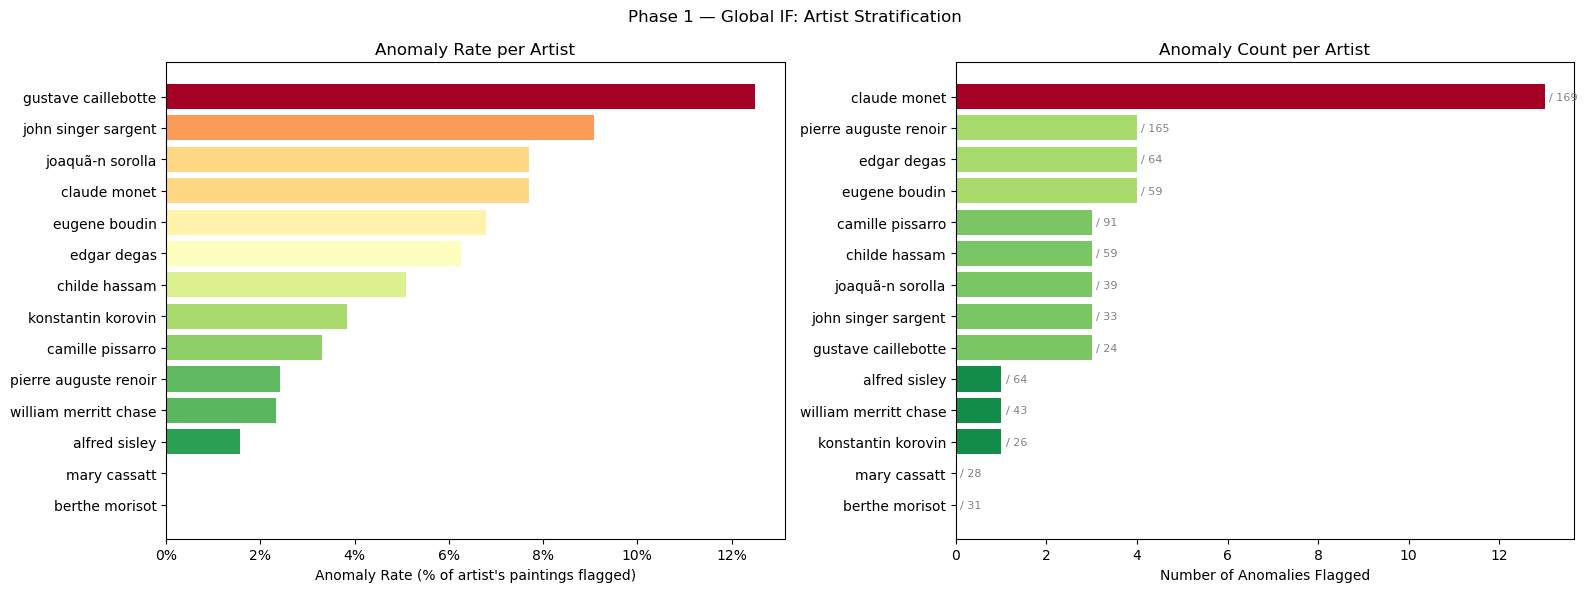

In [7]:
# Artist stratification: count + rate side by side 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
strat_sorted_rate  = stratification.sort_values('anomaly_rate')
strat_sorted_count = stratification.sort_values('n_anomalies')

# anomaly rate
rate_colors = plt.cm.RdYlGn_r(
    (strat_sorted_rate['anomaly_rate'] - strat_sorted_rate['anomaly_rate'].min()) /
    (strat_sorted_rate['anomaly_rate'].max() - strat_sorted_rate['anomaly_rate'].min() + 1e-9)
)
axes[0].barh(strat_sorted_rate['artist'], strat_sorted_rate['anomaly_rate'],
             color=rate_colors)
axes[0].set_xlabel('Anomaly Rate (% of artist\'s paintings flagged)')
axes[0].set_title('Anomaly Rate per Artist')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# anomaly count
count_colors = plt.cm.RdYlGn_r(
    (strat_sorted_count['n_anomalies'] - strat_sorted_count['n_anomalies'].min()) /
    (strat_sorted_count['n_anomalies'].max() - strat_sorted_count['n_anomalies'].min() + 1e-9)
)
bars = axes[1].barh(strat_sorted_count['artist'], strat_sorted_count['n_anomalies'],
                    color=count_colors)
for bar, total in zip(bars, strat_sorted_count['n_total']):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                 f'/ {int(total)}', va='center', fontsize=8, color='gray')
axes[1].set_xlabel('Number of Anomalies Flagged')
axes[1].set_title('Anomaly Count per Artist')

plt.suptitle('Phase 1 — Global IF: Artist Stratification', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_artist_stratification.png', dpi=150)
plt.show()

C:\Users\Yeva\AppData\Local\Temp\ipykernel_3712\1821228375.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=artist_order, patch_artist=True, vert=True)


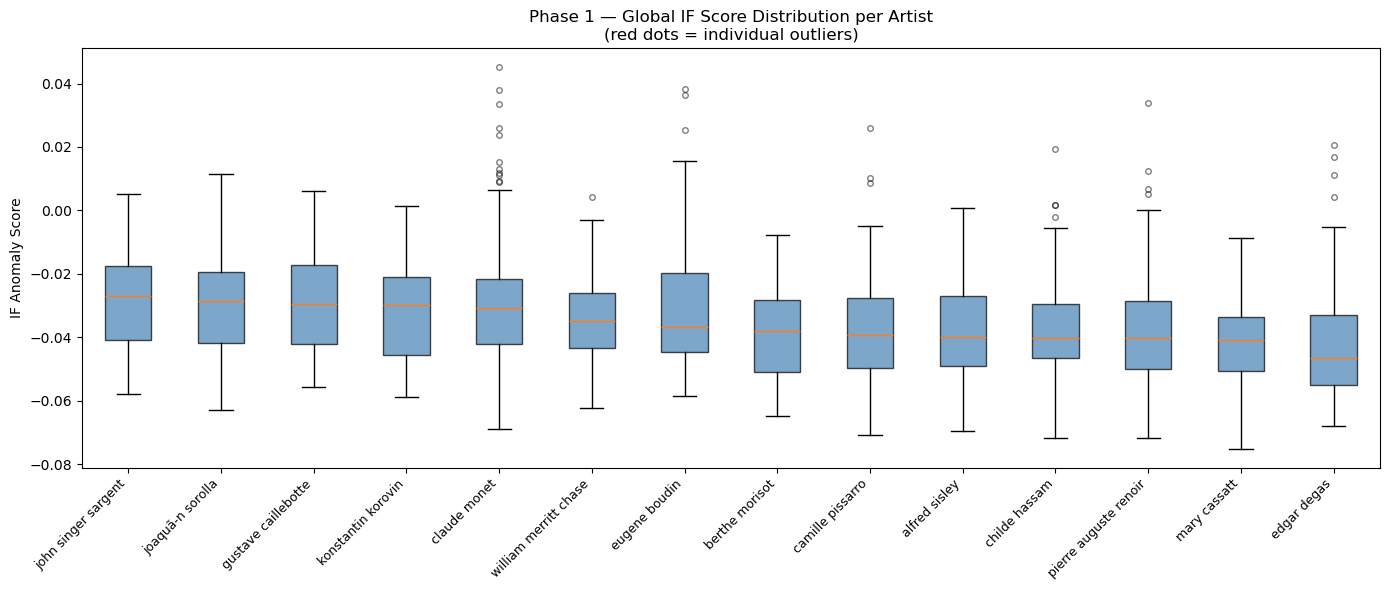

In [8]:
# Score distribution per artist (box plot) 
artist_order = (
    meta_qualified.groupby('artist')['if_global_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data_to_plot = [
    meta_qualified[meta_qualified['artist'] == a]['if_global_score'].values
    for a in artist_order
]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data_to_plot, labels=artist_order, patch_artist=True, vert=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', color='crimson', alpha=0.5, markersize=4)
ax.set_xticklabels(artist_order, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('IF Anomaly Score')
ax.set_title('Phase 1 — Global IF Score Distribution per Artist\n'
             '(red dots = individual outliers)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_artist_boxplot.png', dpi=150)
plt.show()

In [9]:
# Save Phase 1
metadata[['filename', 'artist', 'if_global_score', 'if_global_norm', 'if_global_flag']].to_csv(
    RESULTS_DIR / 'if_phase1_global_scores.csv', index=False
)
print('Saved - results/if_phase1_global_scores.csv')

Saved - results/if_phase1_global_scores.csv


## Phase 2: Per-Artist Isolation Forest (Reduced Dims)

We fit a separate IF on each qualified artist's embeddings, reduced to **10 PCA dimensions**.
This catches paintings that are outliers *within their own artist's style*, even if they're not unusual at the global genre level.

In [10]:
N_ARTIST_DIMS = 10

artist_if_scores  = np.full(len(metadata), np.nan)
artist_if_flags   = np.zeros(len(metadata), dtype=bool)

for artist in qualified_artists:
    idx        = metadata[metadata['artist'] == artist].index.tolist()
    artist_emb = embeddings_pca[idx]
    n_samples  = len(idx)

    # fit per-artist PCA
    n_dims = min(N_ARTIST_DIMS, n_samples - 1)
    pca_artist = PCA(n_components=n_dims, random_state=RANDOM_STATE)
    artist_emb_reduced = pca_artist.fit_transform(artist_emb)

    # fit per-artist IF
    iso_artist = IsolationForest(
        n_estimators=N_ESTIMATORS,
        contamination=CONTAMINATION,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    iso_artist.fit(artist_emb_reduced)

    scores = -iso_artist.decision_function(artist_emb_reduced)
    labels =  iso_artist.predict(artist_emb_reduced)

    for local_i, global_i in enumerate(idx):
        artist_if_scores[global_i] = scores[local_i]
        artist_if_flags[global_i]  = (labels[local_i] == -1)

    n_flagged = (labels == -1).sum()
    print(f'{artist:<30} n={n_samples:>3}  dims={n_dims}  flagged={n_flagged}')

metadata['if_artist_score'] = artist_if_scores
metadata['if_artist_flag']  = artist_if_flags

claude monet                   n=169  dims=10  flagged=9
pierre auguste renoir          n=165  dims=10  flagged=9
camille pissarro               n= 91  dims=10  flagged=5
edgar degas                    n= 64  dims=10  flagged=4
alfred sisley                  n= 64  dims=10  flagged=4
eugene boudin                  n= 59  dims=10  flagged=3
childe hassam                  n= 59  dims=10  flagged=3
william merritt chase          n= 43  dims=10  flagged=3
joaquã­n sorolla               n= 39  dims=10  flagged=2
john singer sargent            n= 33  dims=10  flagged=2
berthe morisot                 n= 31  dims=10  flagged=2
mary cassatt                   n= 28  dims=10  flagged=2
konstantin korovin             n= 26  dims=10  flagged=2
gustave caillebotte            n= 24  dims=10  flagged=2


C:\Users\Yeva\AppData\Local\Temp\ipykernel_3712\2813041529.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data2, labels=artist_order2, patch_artist=True)


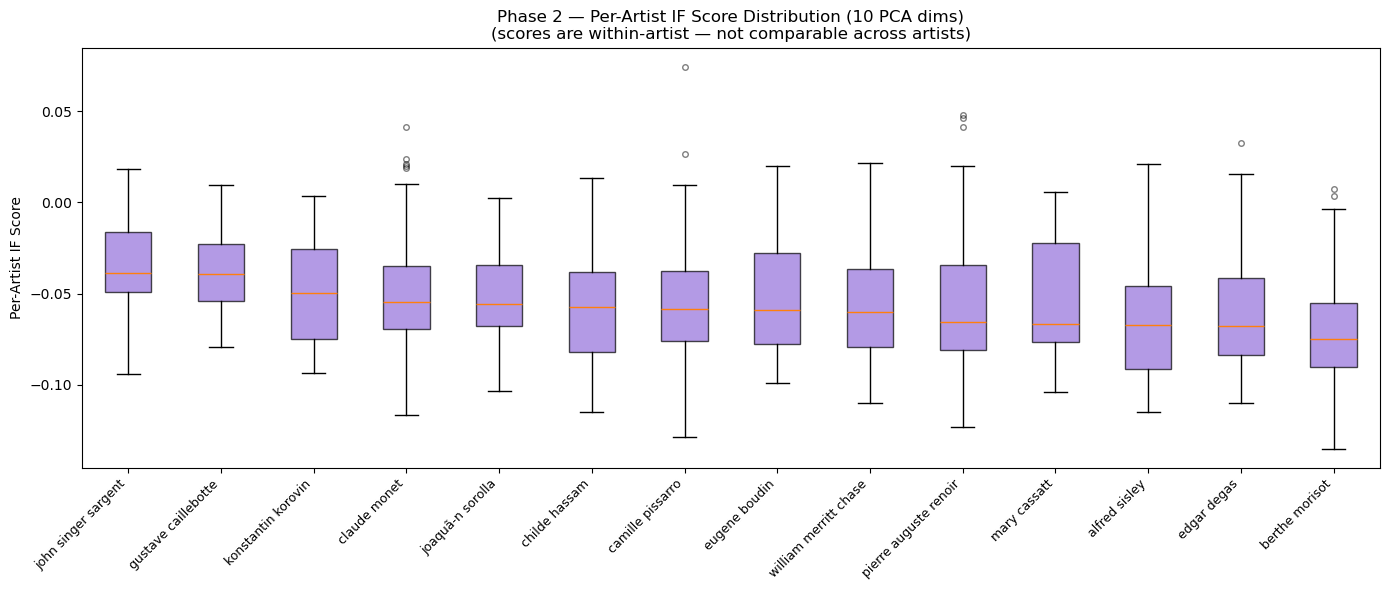

In [11]:
# Per-artist IF: score distribution (box plot)
meta_qualified = metadata[metadata['artist'].isin(qualified_artists)].copy()

artist_order2 = (
    meta_qualified.groupby('artist')['if_artist_score']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data2 = [
    meta_qualified[meta_qualified['artist'] == a]['if_artist_score'].values
    for a in artist_order2
]

fig, ax = plt.subplots(figsize=(14, 6))
bp = ax.boxplot(data2, labels=artist_order2, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('mediumpurple')
    patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', color='crimson', alpha=0.5, markersize=4)
ax.set_xticklabels(artist_order2, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Per-Artist IF Score')
ax.set_title('Phase 2 — Per-Artist IF Score Distribution (10 PCA dims)\n'
             '(scores are within-artist — not comparable across artists)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase2_artist_boxplot.png', dpi=150)
plt.show()

In [12]:
# Top anomaly per artist (Phase 2)
top_per_artist = (
    meta_qualified
    .sort_values('if_artist_score', ascending=False)
    .groupby('artist')
    .first()
    [['filename', 'if_artist_score', 'if_global_score']]
    .sort_values('if_artist_score', ascending=False)
    .reset_index()
)
print('Worst outlier per artist (Phase 2 — per-artist IF):')
print(top_per_artist.to_string(index=False))

Worst outlier per artist (Phase 2 — per-artist IF):
               artist                                                                          filename  if_artist_score  if_global_score
     camille pissarro                      Impressionism/camille-pissarro_peasant-woman-at-the-well.jpg         0.074273         0.025835
pierre auguste renoir                  Impressionism/pierre-auguste-renoir_woman-at-the-garden-1873.jpg         0.047687        -0.008232
         claude monet                                    Impressionism/claude-monet_ships-in-harbor.jpg         0.041292         0.045264
          edgar degas                           Impressionism/edgar-degas_at-saint-valery-sur-somme.jpg         0.032255        -0.032148
william merritt chase                                  Impressionism/william-merritt-chase_seascape.jpg         0.021690         0.004296
        alfred sisley                         Impressionism/alfred-sisley_snow-at-louveciennes-1878.jpg         0.021185

In [13]:
# Phase 1 vs Phase 2 
both_flagged = meta_qualified[
    meta_qualified['if_global_flag'] & meta_qualified['if_artist_flag']
][['filename', 'artist', 'if_global_score', 'if_artist_score']].sort_values(
    'if_global_score', ascending=False
).reset_index(drop=True)

print(f'Flagged by BOTH global and per-artist IF: {len(both_flagged)} paintings')
print(both_flagged.to_string(index=False))

Flagged by BOTH global and per-artist IF: 14 paintings
                                                                     filename                artist  if_global_score  if_artist_score
                               Impressionism/claude-monet_ships-in-harbor.jpg          claude monet         0.045264         0.041292
                   Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg          claude monet         0.033438         0.020887
                               Impressionism/claude-monet_boats-on-rapair.jpg          claude monet         0.025916         0.010225
                 Impressionism/camille-pissarro_peasant-woman-at-the-well.jpg      camille pissarro         0.025835         0.074273
                               Impressionism/claude-monet_the-magpie-1869.jpg          claude monet         0.023767         0.024022
                        Impressionism/edgar-degas_manet-at-the-races-1870.jpg           edgar degas         0.020578         0.006843
Impress

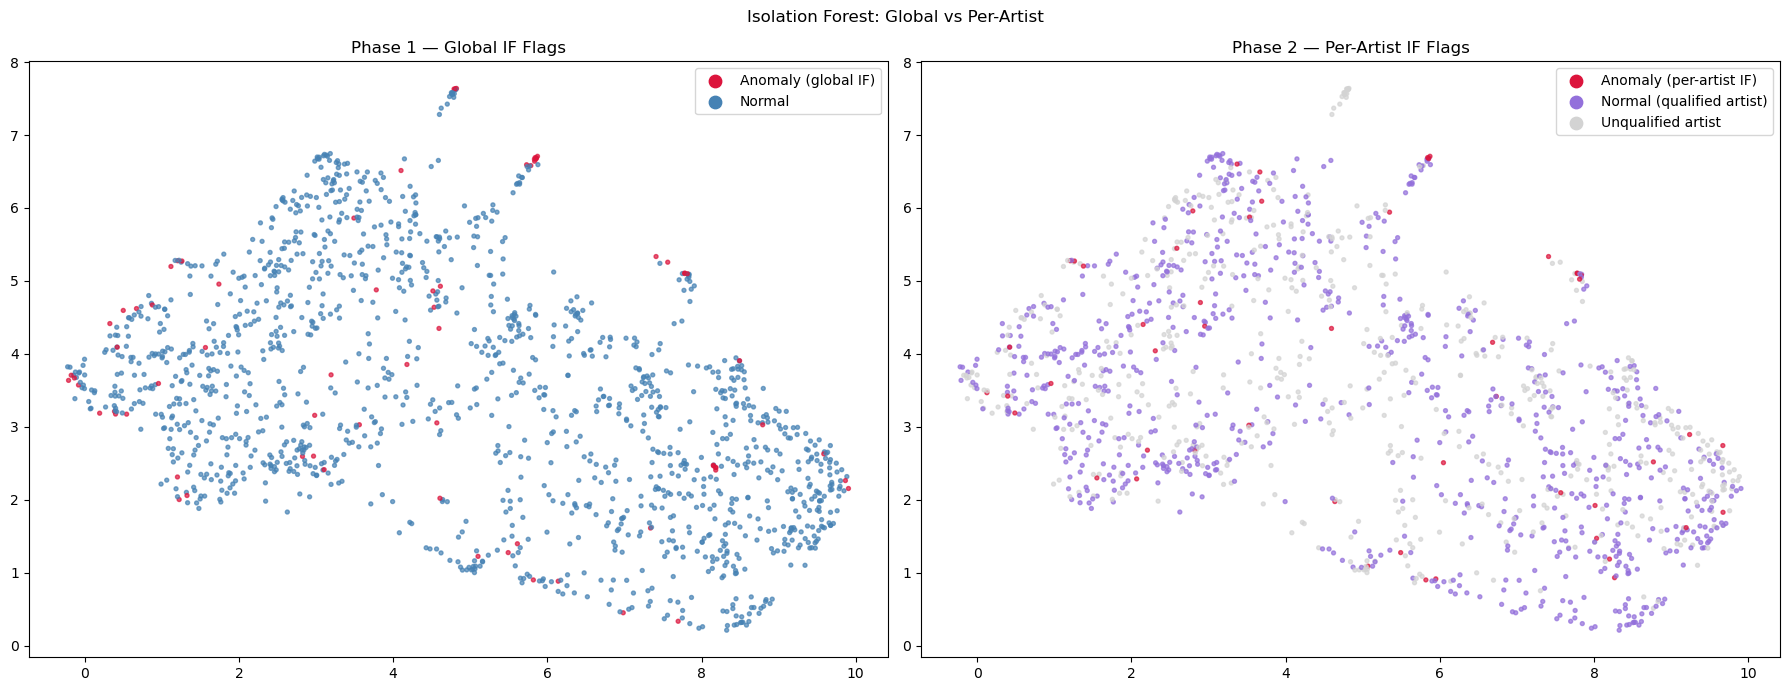

In [14]:
# UMAP: Phase 1 vs Phase 2
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Global IF
colors_global = np.where(metadata['if_global_flag'], 'crimson', 'steelblue')
axes[0].scatter(coords[:, 0], coords[:, 1], c=colors_global, s=8, alpha=0.7)
axes[0].scatter([], [], c='crimson',   s=20, label='Anomaly (global IF)')
axes[0].scatter([], [], c='steelblue', s=20, label='Normal')
axes[0].legend(markerscale=2)
axes[0].set_title('Phase 1 — Global IF Flags')

# Per-artist IF
colors_artist = np.where(
    metadata['if_artist_flag'].fillna(False), 'crimson',
    np.where(metadata['if_artist_score'].isna(), 'lightgrey', 'mediumpurple')
)
axes[1].scatter(coords[:, 0], coords[:, 1], c=colors_artist, s=8, alpha=0.7)
axes[1].scatter([], [], c='crimson',     s=20, label='Anomaly (per-artist IF)')
axes[1].scatter([], [], c='mediumpurple',s=20, label='Normal (qualified artist)')
axes[1].scatter([], [], c='lightgrey',   s=20, label='Unqualified artist')
axes[1].legend(markerscale=2)
axes[1].set_title('Phase 2 — Per-Artist IF Flags')

plt.suptitle('Isolation Forest: Global vs Per-Artist', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'if_phase1_vs_phase2_umap.png', dpi=150)
plt.show()

In [15]:
# Save Phase 2
metadata[['filename', 'artist', 'if_artist_score', 'if_artist_flag']].to_csv(
    RESULTS_DIR / 'if_phase2_artist_scores.csv', index=False
)
print('Saved - results/if_phase2_artist_scores.csv')

Saved - results/if_phase2_artist_scores.csv


## Cross-Method Comparison: All 4 Methods

Combines Cosine Similarity, Wasserstein, KS Test, and Isolation Forest.
Paintings flagged by all 4 are the most confident anomaly candidates in the dataset.

In [16]:
cosine_path = RESULTS_DIR / 'phase1_global_cosine_scores.csv'
swd_path    = RESULTS_DIR / 'wasserstein_phase2_painting_scores.csv'
ks_path     = RESULTS_DIR / 'ks_phase2_painting_scores.csv'

missing = [p for p in [cosine_path, swd_path, ks_path] if not p.exists()]
if missing:
    print('Missing result files — run these notebooks first:')
    for p in missing:
        print(f'  {p.name}')
else:
    cosine_df = pd.read_csv(cosine_path)[['filename', 'global_anomaly_score']]
    swd_df    = pd.read_csv(swd_path)[['filename', 'painting_swd_norm']]
    ks_df     = pd.read_csv(ks_path)[['filename', 'ks_mean_d']]
    if_df     = metadata[['filename', 'artist', 'if_global_norm']]

    # normalize KS 0-1
    ks_df = ks_df.copy()
    ks_df['ks_norm'] = (
        (ks_df['ks_mean_d'] - ks_df['ks_mean_d'].min()) /
        (ks_df['ks_mean_d'].max() - ks_df['ks_mean_d'].min())
    )

    all4 = (
        if_df
        .merge(cosine_df, on='filename', how='inner')
        .merge(swd_df,    on='filename', how='inner')
        .merge(ks_df[['filename', 'ks_norm']], on='filename', how='inner')
    )

    # top 5% per method
    all4['flag_cosine'] = all4['global_anomaly_score'] >= np.percentile(all4['global_anomaly_score'], 95)
    all4['flag_swd']    = all4['painting_swd_norm']    >= np.percentile(all4['painting_swd_norm'],    95)
    all4['flag_ks']     = all4['ks_norm']              >= np.percentile(all4['ks_norm'],              95)
    all4['flag_if']     = all4['if_global_norm']       >= np.percentile(all4['if_global_norm'],       95)
    all4['n_methods']   = (
        all4['flag_cosine'].astype(int) + all4['flag_swd'].astype(int) +
        all4['flag_ks'].astype(int)     + all4['flag_if'].astype(int)
    )

    print('Flagged by N methods:')
    print(all4['n_methods'].value_counts().sort_index().to_string())

Flagged by N methods:
n_methods
0    1290
1     138
2      56
3      14
4       2


In [ ]:
if 'all4' in dir():
    # Flagged by ALL 4 
    consensus4 = (
        all4[all4['n_methods'] == 4]
        [['filename', 'artist', 'global_anomaly_score', 'painting_swd_norm',
          'ks_norm', 'if_global_norm']]
        .sort_values('if_global_norm', ascending=False)
        .reset_index(drop=True)
    )
    print(f'Flagged by ALL 4 methods ({len(consensus4)} paintings):')
    print(consensus4.to_string(index=False))

    # Flagged by exactly 3 methods 
    three_method_combos = {
        'Cosine + SWD + KS (not IF)' : all4['flag_cosine'] & all4['flag_swd']  & all4['flag_ks']  & ~all4['flag_if'],
        'Cosine + SWD + IF (not KS)' : all4['flag_cosine'] & all4['flag_swd']  & all4['flag_if']  & ~all4['flag_ks'],
        'Cosine + KS  + IF (not SWD)': all4['flag_cosine'] & all4['flag_ks']   & all4['flag_if']  & ~all4['flag_swd'],
        'SWD   + KS  + IF (not Cos)' : all4['flag_swd']    & all4['flag_ks']   & all4['flag_if']  & ~all4['flag_cosine'],
    }
    print()
    for label, mask in three_method_combos.items():
        subset = all4[mask][['filename', 'artist', 'global_anomaly_score',
                              'painting_swd_norm', 'ks_norm', 'if_global_norm']]
        print(f'{label} — {len(subset)} paintings:')
        if len(subset) > 0:
            print(subset.sort_values('if_global_norm', ascending=False).to_string(index=False))
        print()

Flagged by ALL 4 methods (2 paintings):
                                                  filename        artist  global_anomaly_score  painting_swd_norm  ks_norm  if_global_norm
     Impressionism/eugene-boudin_the-port-at-deauville.jpg eugene boudin              0.617426           0.807678 0.891050        0.942913
Impressionism/claude-monet_gestrandetes-boot-in-fecamp.jpg  claude monet              0.614853           0.830763 0.927389        0.901746

Cosine + SWD + KS (not IF) — 1 paintings:
                                                   filename                artist  global_anomaly_score  painting_swd_norm  ks_norm  if_global_norm
Impressionism/pierre-auguste-renoir_young-woman-reading.jpg pierre auguste renoir              0.610034           0.828408 0.646945         0.46077

Cosine + SWD + IF (not KS) — 0 paintings:

Cosine + KS  + IF (not SWD) — 7 paintings:
                                                             filename                 artist  global_anomaly_score  p

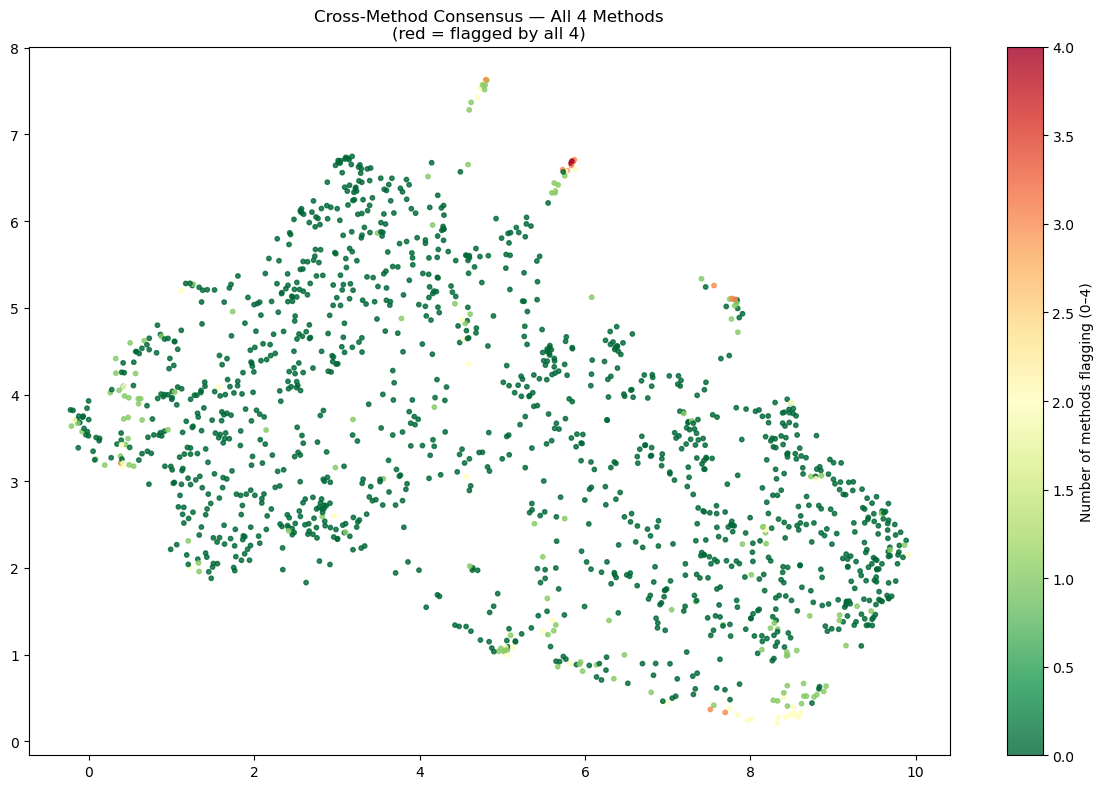

Saved - results/cross_method_all4_scores.csv

All done. Four methods complete: Cosine / Wasserstein / KS / Isolation Forest.


In [17]:
if 'all4' in dir():
    # UMAP coloured by number of agreeing methods
    fig, ax = plt.subplots(figsize=(12, 8))
    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=all4['n_methods'], cmap='RdYlGn_r',
                    vmin=0, vmax=4, s=10, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='Number of methods flagging (0–4)')
    ax.set_title('Cross-Method Consensus — All 4 Methods\n'
                 '(red = flagged by all 4)')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'if_cross_method_consensus_umap.png', dpi=150)
    plt.show()

    # Save full 4-method scores
    all4.to_csv(RESULTS_DIR / 'cross_method_all4_scores.csv', index=False)
    print('Saved - results/cross_method_all4_scores.csv')
    print()
    print('All done. Four methods complete: Cosine / Wasserstein / KS / Isolation Forest.')